# Figure workshop

Every figure in `figures/` is defined here. To
regenerate them, run the notebook top to bottom and then the Save cell
near the bottom.

Each figure cell builds a `fig` and stashes it in `FIGS` via `keep()`,
which returns nothing on purpose: the inline backend already renders
whatever a cell creates, so returning the figure would draw it twice.
Nothing reaches disk until the Save cell runs.

Re-run the setup cell after editing it, since `keep` is defined
there.


In [224]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from constellaration_uq.data import filter_valid, load_raw
from constellaration_uq.metrics import (
    coverage,
    crps_gaussian,
    deferral_curve,
    distance_bins,
    pit_values,
)
from constellaration_uq.results import REPO_ROOT, load_results
from constellaration_uq.splits import (
    hole_split,
    tail_split,
)

DATA_DIR = REPO_ROOT / 'data_raw' / 'data'
FIGURES_DIR = REPO_ROOT / 'figures'
AXIS = 'metrics.aspect_ratio'
TEST_FRACTION = 0.2

# Percentile 30, so the band runs 20 to 40. Chosen from scripts/hole_placement.py:
# it sits immediately above the tail's percentiles 0 to 20 without overlapping,
# so the hole-versus-edge contrast controls for local sparsity. Defined once here
# because several figures use it and a hardcoded default would drift between them.
HOLE_CENTRE = 0.30

FIGS = {}


def keep(fig, name):
    """Stash a figure for the save cell.

    Deliberately returns nothing. %matplotlib inline already renders every
    figure a cell creates, so returning it would make the cell's output value
    render it a second time and every figure would appear twice.
    """
    FIGS[name] = fig


SEEDS = [0, 1, 2]
COVERAGE_LEVEL = 0.9


def points_for(split, seed):
    """Per-point predictions for one split at one replication seed.

    Seed 0 owns the unsuffixed filename, which is what let replication be
    additive: no script that already read these files had to learn about seeds.
    """
    stem = f'mv_ensemble_{split}' + ('' if seed == 0 else f'_s{seed}')
    return pd.read_csv(REPO_ROOT / 'results' / f'{stem}_points.csv')


def band(ax, x, curves, color, alpha=0.18):
    """Min-max envelope across seeds. Returns the mean for the caller to draw.

    Min-max rather than mean plus or minus one standard deviation. Three seeds
    do not estimate a standard deviation, and a symmetric ribbon would imply a
    precision this does not have.

    What the band means: the hole and tail held-out sets are quantile cutoffs
    with no random component, so they are IDENTICAL across seeds. The spread is
    retraining variability on a fixed test set, not sampling error over shapes.
    """
    stack = np.vstack(curves)
    ax.fill_between(x, stack.min(axis=0), stack.max(axis=0), color=color, alpha=alpha, lw=0)
    return stack.mean(axis=0)


## Style

Edit here rather than per figure. The same colour must mean the same thing
everywhere, which matters more than any individual choice.

In [225]:
# One width for every figure, so the saved PNGs line up when several are shown
# together. Heights still vary with content.
FIG_WIDTH = 7

COLOR_TRAIN =  '#969696' # matches COLOR_NEUTRAL, the in-region color used in cell 37
COLOR_TAIL = '#d94801'
COLOR_HOLE = '#2171b5'
COLOR_ALEATORIC = '#6a51a3'
COLOR_NEUTRAL = '#525252'

plt.rcParams.update(
    {
        # Any figure that does not pass figsize explicitly inherits this, so the
        # width belongs here too or that figure alone comes out narrower.
        'figure.figsize': (FIG_WIDTH, 4.5),
        'figure.dpi': 100,
        'savefig.dpi': 100,
        'savefig.bbox': 'tight',
        'axes.grid': True,
        'grid.alpha': 0.25,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.size': 10,
    }
)

## Load the axis

Slow cell, roughly 10 to 20 seconds, almost all of it reading parquet. Only the
aspect ratio column is needed, never the 80-coefficient flatten. Run once.

In [226]:
for _, _df in filter_valid(load_raw(DATA_DIR)):
    pass

axis = _df[AXIS].to_numpy()
print(f'{len(axis):,} rows, aspect ratio {axis.min():.2f} to {axis.max():.2f}')

27,050 rows, aspect ratio 3.92 to 12.11


## Figure 1: where the cuts fall

The explanatory figure. Shows the sampling density, where the tail cut lands,
and how narrow the hole is by comparison.

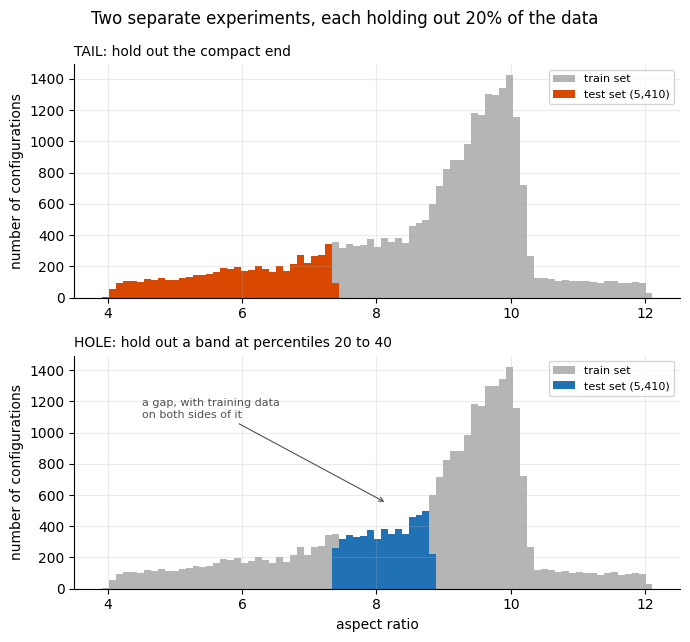

In [227]:
_, tail_test = tail_split(axis, 'low', TEST_FRACTION)
_, hole_test = hole_split(axis, TEST_FRACTION, HOLE_CENTRE)

fig, (ax_tail, ax_hole) = plt.subplots(2, 1, sharex=False, figsize=(FIG_WIDTH, 6.5))
bins = np.linspace(axis.min(), axis.max(), 80)

panels = [
    (ax_tail, tail_test, COLOR_TAIL, 'TAIL: hold out the compact end'),
    (ax_hole, hole_test, COLOR_HOLE, 'HOLE: hold out a band at percentiles 20 to 40'),
]

for ax, test_mask, color, title in panels:
    ax.hist(axis, bins=bins, color=COLOR_TRAIN, label='train set', alpha=0.7)
    ax.hist(axis[test_mask], bins=bins, color=color, label=f'test set ({test_mask.sum():,})')
    ax.set_ylabel('number of configurations')
    ax.set_title(title, fontsize=10, loc='left')
    ax.legend(fontsize=8)

# Tip height derived from the bars so it lands on them rather than above.
hole_counts, _ = np.histogram(axis[hole_test], bins=bins)

ax_hole.annotate(
    'a gap, with training data\non both sides of it',
    xy=(axis[hole_test].mean(), hole_counts.max() * 1.10),
    xytext=(axis.min() + 0.6, hole_counts.max() * 2.2),
    fontsize=8,
    color=COLOR_NEUTRAL,
    arrowprops={'arrowstyle': '->', 'color': COLOR_NEUTRAL, 'lw': 0.8},
)


ax_hole.set_xlabel('aspect ratio')
fig.suptitle('Two separate experiments, each holding out 20% of the data')
fig.tight_layout()

keep(fig, 'split_design')

## Table 1: does the pipeline reproduce Appendix A.4?

Before any claim of our own. Proxima's Appendix A.4 trains an ensemble of ten
MLPs on these boundary coefficients and reports Table 7. If our loader, filters,
trimming, scaling and architecture are right, our numbers should land near
theirs. If they do not, nothing downstream can be trusted.

**The headline row is the first one**, our plain-MSE ensemble against theirs.
That is the like-for-like comparison: A.4 trained by minimising mean squared
error, so comparing a mean-variance ensemble's RMSE to it would compare two
different training objectives.

**The other two rows are the consistency check**, and they matter more than they
look. One untuned single MLP lands at 2.4x Table 7 on edge rotational transform
and 2.8x on log10 qi. **A pipeline bug would not produce a consistent factor
across two unrelated metrics**; it would break one and not the other, or break
both differently. Two similar ratios is positive evidence the plumbing is right.

**RMSE only, never R².** Ours is 0.982 against their 0.997, which reads far
worse than the RMSE ratio implies, because R² depends on the test set's own
spread: 0.0789 for us against roughly 0.115 back-solved from their table. RMSE
is the comparable number and R² is not.

**There is no log10 qi ensemble.** That row is a single untuned MLP from the
day 1-2 grid and is labelled as such. A second target is optional scope,
deliberately deferred, and quoting 2.8x as "our qi result" would be wrong.

**Our pool is 27,050 against A.4's stated ~23k**, applying every filter their
published loader performs. Two intermediate counts land exactly on published
figures (158,685 evaluated without errors, 68,191 at NFP=3), so the chain is
right and their appendix is incomplete somewhere. Documented rather than forced.


In [228]:
mse = load_results('mse_ensemble')['results']
grid_rows = load_results('day_1_2_grid')['results']['rows']


def grid_in_region(target):
    """In-region RMSE for one target from the day 1-2 grid.

    Averaged over the three cuts of the winning axis. Each is a separate fit of
    the same untuned single MLP, and they differ only in which rows were held
    out, so their in-region numbers are three samples of one quantity.
    """
    matching = [
        r['rmse_in'] for r in grid_rows if r['target'] == target and r['axis'] == 'aspect_ratio'
    ]
    return float(np.mean(matching))


# Table 7 values, transcribed from the paper. Stored in the results file for the
# primary target; the qi figure has no run of ours to sit beside it.
TABLE_7 = {
    'edge_rotational_transform_over_n_field_periods': mse['table_7_rmse'],
    'log_10_qi': 0.051,
}

comparison = pd.DataFrame(
    [
        {
            'metric': 'edge rotational transform',
            'model': 'ours: 10-member MSE ensemble',
            'table_7_rmse': TABLE_7['edge_rotational_transform_over_n_field_periods'],
            'our_rmse': mse['ensemble_rmse'],
        },
        {
            'metric': 'edge rotational transform',
            'model': 'ours: one untuned MLP',
            'table_7_rmse': TABLE_7['edge_rotational_transform_over_n_field_periods'],
            'our_rmse': grid_in_region('edge_rot_transform'),
        },
        {
            'metric': 'log10 qi',
            'model': 'ours: one untuned MLP (no ensemble run)',
            'table_7_rmse': TABLE_7['log_10_qi'],
            'our_rmse': grid_in_region('log10_qi'),
        },
    ]
)
comparison['ratio'] = comparison['our_rmse'] / comparison['table_7_rmse']
comparison.round({'table_7_rmse': 4, 'our_rmse': 5, 'ratio': 2})

,metric,model,table_7_rmse,our_rmse,ratio
0,edge rotational transform,ours: 10-member MSE ensemble,0.006,0.01052,1.75
1,edge rotational transform,ours: one untuned MLP,0.006,0.01458,2.43
2,log10 qi,ours: one untuned MLP (no ensemble run),0.051,0.14489,2.84


## Table 2: the decomposition, and where calibration breaks

The project's headline. Three splits, each training its own ten-member
mean-variance ensemble on the same architecture and recipe, evaluated on two
held-out sets: a slice carved from inside the training region, and the split's
own out-of-region set.

**Read the `ratio` column.** It is predicted uncertainty divided by the error it
is predicting. 1.0 is honest, above 1.0 is cautious, below 1.0 is overconfident.

In region it runs 1.04 to 1.18 on all three splits, so the model is slightly
cautious, which is the safe direction. Out of region it falls to 0.69 for the
hole and 0.66 for the tail. **The random split is the control** and stays near
its in-region value, which is what makes the other two readable as shift rather
than as an artifact of the diagnostic.

`cov@0.9` is the same failure in the form a deferral threshold can use: the
stated 90% interval holds 0.95 to 0.97 of the truth in region and 0.779 at the
tail. `pit_mean` separates two faults that coverage cannot: below 0.5 means the
prediction itself is drifting, not merely that the interval is too narrow.

**Every number here is seed 0**, as is every coverage, PIT, CRPS and deferral
figure in this project. It is not the only seed run: all three splits were
replicated over seeds 0, 1 and 2, and Table 3 below carries the spreads. Seed 0
stays the plotted value so the table and the figures agree.

**The tail's out-of-region set is conservative by about 2%.** The 0.05%
target trim reads held-out labels, and 22 of the 28 rows it removes fall inside
this split's held-out region. Restoring the ordinary ones moves the ratio from
3.24x to 3.31x. Measured, not assumed: see decision log 1.4.


In [229]:
calibration = load_results('calibration')['results']

LABELS = {'random': 'random', 'hole': 'hole p30', 'tail': 'tail-low'}

decomposition = pd.DataFrame(
    [
        {
            'split': LABELS[name],
            'region': region.replace('-region', '').replace('-of', ''),
            'n': sets[region]['n'],
            'rmse': sets[region]['rmse'],
            'epistemic': sets[region]['epistemic'],
            'aleatoric': sets[region]['aleatoric'],
            'total': sets[region]['total'],
            'ratio': sets[region]['total_over_rmse'],
            'cov@0.9': sets[region]['coverage_0.9'],
            'pit_mean': sets[region]['pit_mean'],
        }
        for name in ('random', 'hole', 'tail')
        for sets in [calibration[name]['sets']]
        for region in ('in-region', 'out-of-region')
    ]
)
decomposition.round(
    {'rmse': 5, 'epistemic': 5, 'aleatoric': 5, 'total': 5, 'ratio': 2, 'cov@0.9': 3, 'pit_mean': 3}
)

,split,region,n,rmse,epistemic,aleatoric,total,ratio,cov@0.9,pit_mean
0,random,in,4324,0.01256,0.00887,0.01194,0.01487,1.18,0.966,0.518
1,random,out,5404,0.01280,0.00895,0.01161,0.01466,1.15,0.962,0.514
2,hole p30,in,4324,0.01252,0.00813,0.01010,0.01297,1.04,0.950,0.506
3,hole p30,out,5404,0.02484,0.01197,0.01209,0.01702,0.69,0.871,0.531
4,tail-low,in,4324,0.01223,0.00834,0.01032,0.01327,1.09,0.956,0.507
5,tail-low,out,5405,0.03962,0.01457,0.02189,0.02630,0.66,0.779,0.348


## Table 3: does it survive a different seed?

Table 2 rests on differences between three ensembles. That only means something
if a fourth ensemble trained the same way would land in the same place, so
`scripts/seed_spread.py` re-measures every quantity over seeds 0, 1 and 2.

**What the seed moves, and what it does not.** Member initialisation, shuffle
order, the in-region slice and the validation set all vary. **The hole and tail
held-out sets do not**, since they are quantile cutoffs on the aspect ratio axis
with no random component. So the out-of-region columns are replicated on a fixed
test set, and only the random split's test set moves.

**Member seeds are spaced by the ensemble size**, `base_seed = seed * 10`.
`train_mv_ensemble` assigns member seeds as `base_seed + k`, so consecutive
replication seeds would otherwise share nine of ten member initialisations and
this table would measure almost nothing.

**The finding.** Seed noise runs 0.2% to 6.7%, and every claim in Table 2 clears
it by roughly an order of magnitude. The three `out/in rmse` ranges do not come
close to overlapping. **The random split is the control** and its gap is
1.03 ± 0.01, so the diagnostic does not manufacture a gap where there is none.

Incidental, and it cuts the right way: seed 0 is the most conservative seed on
the tail, gap 3.24 against a mean of 3.32, so the published headline understates
the effect rather than flattering it.


In [230]:
seed_spread = load_results('seed_spread')['results']


def pm(stat, places):
    """Format a mean and its spread into one cell.

    Strings rather than floats on purpose: a float column would render the mean
    and silently drop the spread, which is the half that makes the row a claim
    rather than a number.
    """
    return f'{stat["mean"]:.{places}f} ± {stat["std"]:.{places}f}'


replication = pd.DataFrame(
    [
        {
            'split': LABELS[name],
            'seeds': len(split['seeds']),
            'out/in rmse': pm(summary['gap'], 2),
            'in ratio': pm(summary['in_ratio'], 3),
            'out ratio': pm(summary['out_ratio'], 3),
            'out cov@0.9': pm(summary['out_coverage'], 3),
            'out pit_mean': pm(summary['out_pit_mean'], 3),
        }
        for name in ('random', 'hole', 'tail')
        for split in [seed_spread['splits'][name]]
        for summary in [split['summary']]
    ]
)
replication

,split,seeds,out/in rmse,in ratio,out ratio,out cov@0.9,out pit_mean
0,random,3,1.03 ± 0.01,1.140 ± 0.039,1.105 ± 0.047,0.959 ± 0.003,0.509 ± 0.008
1,hole p30,3,1.90 ± 0.12,1.075 ± 0.072,0.725 ± 0.028,0.878 ± 0.005,0.534 ± 0.002
2,tail-low,3,3.32 ± 0.10,1.132 ± 0.034,0.677 ± 0.021,0.788 ± 0.017,0.353 ± 0.012


## Hole placement: a decision, not a figure

The placement sweep asked one question, where to centre the interior hole, and
answered it: percentile 30, which sits immediately above the tail's percentiles
0 to 20 without overlapping them. That makes it a design-decision record, so it
is a table.

Two earlier attempts to plot it are gone. Both drew eight independent
experiments as points on a single axis, and both were misread, because nothing
in that picture tells a reader that each point is its own model fit rather than
a sample from one curve.

`results/hole_placement.json` is the 20% sweep, centres p20 to p80.
`results/hole_placement_narrow.json` is a 10% sweep, centres p10 to p90, and it
is the only run that reaches the sparse upper end. The narrow run shows the
penalty is a U in placement, lowest in the dense middle and rising at both ends,
which means gap width rather than proximity to the compact edge drives most of
it. Treat that as suggestive: its two load-bearing rows carry about 130 points
in their thinnest distance bin against roughly 310 elsewhere, at a single seed.


In [231]:
sweep = load_results('hole_placement')['results']['rows']

pd.DataFrame(sweep)[
    [
        'split',
        'percentiles',
        'n_held_out',
        'rmse_in',
        'rmse_out',
        'ratio',
        'reach',
        'min_bin',
        'delta',
    ]
].round({'rmse_in': 5, 'rmse_out': 5, 'ratio': 2, 'reach': 2, 'delta': 3})

,split,percentiles,n_held_out,rmse_in,rmse_out,ratio,reach,min_bin,delta
0,tail-low,0 to 20,5405,0.01379,0.04157,3.02,2.13,276,0.059
1,hole,10 to 30,5404,0.01417,0.02777,1.96,0.63,602,0.040
2,hole,20 to 40,5404,0.01452,0.02615,1.80,0.45,583,0.041
3,hole,30 to 50,5404,0.01479,0.01658,1.12,0.31,586,0.040
4,hole,40 to 60,5404,0.01476,0.01406,0.95,0.20,641,0.039
5,hole,50 to 70,5404,0.01526,0.01377,0.90,0.16,616,0.039
6,hole,60 to 80,5404,0.01552,0.01240,0.80,0.14,645,0.039
7,hole,70 to 90,5404,0.01567,0.01283,0.82,0.13,602,0.040


## Figure 2: error against distance from the training data

Deliverable one, in single-model form. Every point on these curves is a bin of
roughly 675 held-out configurations rather than a whole experiment, which is
what makes it readable in a way the placement sweep never was.

Three splits, one MLP each, same recipe as the day 1-2 grid. Each curve starts
at that split's own in-region error, measured on a held-out slice carved from
the training region, then follows the binned error outward.

**The finding.** At matched distance the tail sits above the hole by about 12%
over the whole shared range (0.02929 against 0.02615). So most of the headline
gap, 3.02 against 1.80, is distance rather than edge: the tail split simply asks
about configurations much further from the data. What survives after distance is
controlled for is the edge cost itself, and it is real but modest.

Measured in identical fixed-width windows by `distance_error.matched_windows`
and saved to `results/distance_error_matched.csv`. An earlier version of this
cell read "roughly 15% at both 0.2 and 0.4 std out", derived by reading the two
binned curves at their bin medians. The bins are equal-count, so their widths
differ where the splits differ in density, and a wide bin's RMSE is dominated by
its far edge. Do not read a trend across the windows either: four of the five
sit between 1.03 and 1.13 with no ordering.

**This is the weakest claim in the project, and the only one near seed noise.**
The 12% above is seed 0. Across seeds 0, 1 and 2 the premium is 1.156 ± 0.052
(1.119, 1.119, 1.229), so roughly three standard deviations from no effect, where
every other headline clears its seed noise by about an order of magnitude. Read it
as a real but modest edge cost, not as a measured constant. `matched_premium` in
`results/seed_spread.json`.

The shaded band is the only range where both splits have points, so it is the
only range where that comparison exists at all. Past 0.45 the tail continues
alone, and nothing can be said about how a gap would behave out there.

That band also replaces what used to be a separate reach histogram. It made the
same point, was repeatedly misread, and the two numbers it carried now live in
the placement table's `reach` column and in the band's own annotation.

Reads `results/distance_error.json`. Per-point rows are in
`results/distance_error_points.csv` if the bins ever need redrawing.


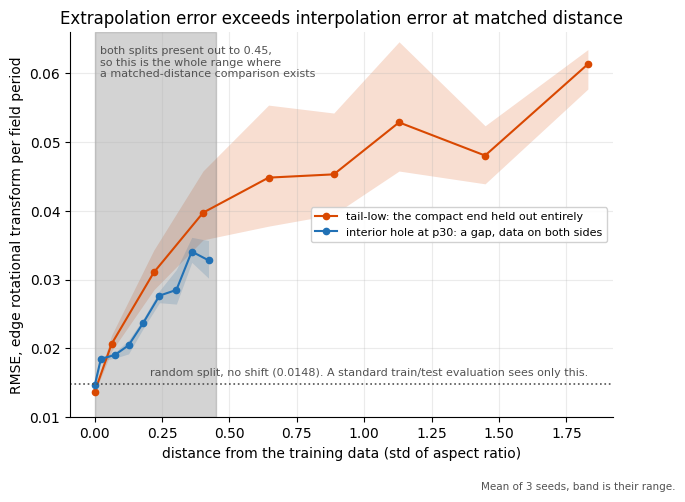

In [232]:
# Three independent fits per split. The bins are identical across seeds, since
# distance depends only on the axis and the training mask and both splits use
# fixed quantile cutoffs, so the curves can be averaged pointwise.
by_seed = [
    load_results('distance_error' + ('' if s == 0 else f'_s{s}'))['results']['splits']
    for s in SEEDS
]
splits = by_seed[0]

SERIES = {
    'tail_low': ('tail-low: the compact end held out entirely', COLOR_TAIL),
    'hole_p30': ('interior hole at p30: a gap, data on both sides', COLOR_HOLE),
}

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 5))

# Pinned so the other annotations below have somewhere reliable to sit.
ax.set_ylim(0.010, 0.066)

for name, (label, color) in SERIES.items():
    # Each curve starts from its own in-region error at distance zero rather
    # than from a shared baseline. The two differ by about 5%, and drawing one
    # line for both would hide that.
    d = [0.0, *[b['d_median'] for b in splits[name]['bins']]]
    curves = [
        [seed[name]['in_region']['rmse'], *[b['rmse'] for b in seed[name]['bins']]]
        for seed in by_seed
    ]
    err = band(ax, d, curves, color)
    ax.plot(d, err, 'o-', color=color, markersize=4.5, label=label)

# The random split is a reference level, not a series. Its held-out points never
# get more than 0.01 from training data, so drawn as a curve it is eight dots on
# the y axis that read as noise on the other two. As a line it does the job it is
# actually for: making the vertical gap to the no-shift baseline readable at
# every distance.
random = splits['random']
far = splits['tail_low']['bins'][-1]['d_median']
ax.axhline(random['rmse_out'], color=COLOR_NEUTRAL, linestyle=':', linewidth=1.2)
ax.annotate(
    f'random split, no shift ({random["rmse_out"]:.4f}). '
    'A standard train/test evaluation sees only this.',
    (far, random['rmse_out']),
    textcoords='offset points',
    xytext=(0, 6),
    ha='right',
    fontsize=8,
    color=COLOR_NEUTRAL,
)

# The hole cannot reach past here, so neither can the comparison. Sits inside
# the band, top left, where both curves are still low.
overlap = splits['hole_p30']['reach']
ax.axvspan(0, overlap, color=COLOR_NEUTRAL, alpha=0.25)
ax.annotate(
    f'both splits present out to {overlap:.2f},\nso this is the whole range where\n'
    'a matched-distance comparison exists',
    (0.02, 0.064),
    va='top',
    ha='left',
    fontsize=8,
    color=COLOR_NEUTRAL,
)

ax.set_xlabel('distance from the training data (std of aspect ratio)')
ax.set_ylabel('RMSE, edge rotational transform per field period')
ax.set_title('Extrapolation error exceeds interpolation error at matched distance')
ax.legend(fontsize=8, loc='center right', framealpha=0.9)

# Below the axes, not inside them. Every free corner of this panel is one a
# curve reaches at some seed, and a caption that collides with data is worse
# than no caption.
fig.text(
    0.99,
    -0.02,
    f'Mean of {len(SEEDS)} seeds, band is their range.',
    ha='right',
    va='top',
    fontsize=7.5,
    color=COLOR_NEUTRAL,
)

keep(fig, 'distance_error')

## Load the uncertainty results

Everything below reads `results/*.json` and `results/*.csv` written by
`scripts/calibration.py`, `scripts/deferral.py` and `scripts/n_sweep.py`. No
training, no parquet, under a second.


In [233]:
cal = load_results('calibration')
calibration = cal['results']
LEVELS = cal['constants']['LEVELS']

sweep = load_results('n_sweep')
sweep_cells = sweep['results']['cells']
sweep_avg = sweep['results']['averaged']

# pts.split would call DataFrame.split, not the column. Always bracket it.
pit_points = pd.read_csv(REPO_ROOT / 'results' / 'calibration_points.csv')

print('splits:', list(calibration))
print('nominal levels:', LEVELS)
print('sweep cells:', len(sweep_cells), 'complete:', sweep['results']['complete'])


splits: ['random', 'hole', 'tail']
nominal levels: [0.5, 0.68, 0.8, 0.9, 0.95, 0.99]
sweep cells: 30 complete: True


## Figure 3: the stated interval stops being the stated interval

Deliverable one in its actionable form, and the figure a deferral threshold
rests on. Same x axis as Figure 2, by construction: both use
`metrics.distance_bins`, so the two can be read side by side and the second
answers what the first leaves open.

Figure 2 says the error grows with distance. That alone is not a problem, since
a model that reports larger error bars as it gets worse is behaving correctly.
This asks whether it does. The y axis is the fraction of truths that actually
landed inside the model's own 90% interval, so an honest model tracks the
dotted line at every distance.

**The finding.** It does not. In region the interval holds 95 to 97%, slightly
conservative. Past the compact edge it falls to 59%, so a stated 90% interval
is closer to a 60% interval out there. The hole degrades too but shallower, and
it flattens rather than continuing down.


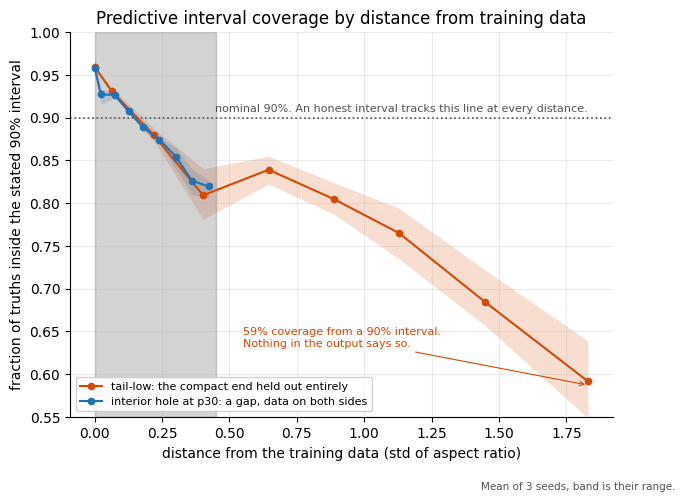

In [234]:
def coverage_by_distance(split, seed):
    """Coverage at nominal 90% per distance bin, for one seed.

    Recomputed here rather than read from calibration.json, which only covers
    seed 0. Uses the same metrics.distance_bins and metrics.coverage the script
    uses, so the seed 0 curve reproduces calibration_bins.csv exactly.
    """
    df = points_for(split, seed)
    out = df[df['region'] == 'out']
    rows, masks = distance_bins(out['distance'].to_numpy(), N_DISTANCE_BINS)
    per_bin = [
        coverage(
            out['y_true'].to_numpy()[m],
            out['mean'].to_numpy()[m],
            out['total_variance'].to_numpy()[m],
            COVERAGE_LEVEL,
        )
        for m in masks
    ]
    anchor = df[df['region'] == 'in']
    in_region = coverage(
        anchor['y_true'], anchor['mean'], anchor['total_variance'], COVERAGE_LEVEL
    )
    return [0.0, *[r['d_median'] for r in rows]], [in_region, *per_bin]


N_DISTANCE_BINS = cal['constants']['N_BINS']

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 5))

SERIES = {
    'tail': ('tail-low: the compact end held out entirely', COLOR_TAIL),
    'hole': ('interior hole at p30: a gap, data on both sides', COLOR_HOLE),
}

curves = {}

for name, (label, color) in SERIES.items():
    # In-region is one anchor at distance zero, not the first bin, matching the
    # convention in Figure 2 and in scripts/calibration.py.
    per_seed = [coverage_by_distance(name, s) for s in SEEDS]
    d = per_seed[0][0]
    cov = band(ax, d, [c for _, c in per_seed], color)
    ax.plot(d, cov, 'o-', color=color, markersize=4.5, label=label)
    curves[name] = (d, cov)

ax.axhline(0.9, color=COLOR_NEUTRAL, linestyle=':', linewidth=1.2)
# Right-aligned at the far edge. On the left it sat inside the shaded band, on
# top of both curves where they are still near 0.9.
ax.annotate(
    'nominal 90%. An honest interval tracks this line at every distance.',
    (max(curves['tail'][0]), 0.905),
    fontsize=8,
    color=COLOR_NEUTRAL,
    ha='right',
    va='bottom',
)

overlap = max(b['d_hi'] for b in calibration['hole']['bins'])
ax.axvspan(0, overlap, color=COLOR_NEUTRAL, alpha=0.25)

# Seed 0, matching the number quoted in the text and in calibration.json.
worst = calibration['tail']['bins'][-1]
ax.annotate(
    f'{worst["coverage_0.9"]:.0%} coverage from a 90% interval.\nNothing in the output says so.',
    xy=(worst['d_median'], worst['coverage_0.9']),
    xytext=(0.55, 0.655),
    fontsize=8,
    color=COLOR_TAIL,
    ha='left',
    va='top',
    arrowprops={'arrowstyle': '->', 'color': COLOR_TAIL, 'lw': 0.8},
)

ax.set_ylim(0.55, 1.0)
ax.set_xlabel('distance from the training data (std of aspect ratio)')
ax.set_ylabel('fraction of truths inside the stated 90% interval')
ax.set_title('Predictive interval coverage by distance from training data')
ax.legend(fontsize=8, loc='lower left', framealpha=0.9)

fig.text(
    0.99,
    -0.02,
    f'Mean of {len(SEEDS)} seeds, band is their range.',
    ha='right',
    va='top',
    fontsize=7.5,
    color=COLOR_NEUTRAL,
)

keep(fig, 'coverage_distance')

## Figure 3b: is the tail biased, or just imprecise?

Coverage says how far off the intervals are. It cannot say which way, and two
different faults produce the same coverage number: an interval that is
honestly centred but too narrow, or one that is the right width but centred on
the wrong value. Widening the error bars fixes the first and does nothing for
the second.

PIT separates them. `metrics.pit_values` is where each truth landed inside its
own predicted distribution, on 0 to 1. Averaged over points, unbiased sits at
0.5. Below 0.5 means the truth keeps landing under the predicted mean, which is
a mean bias, not a width problem.

**The finding.** The interior hole sits flat at 0.52 to 0.55 across its whole
range, no trend. The tail is already at 0.43 in its nearest bin and falls to
0.15 at the furthest distance measured. Same distance-binning as Figure 3, so
the two figures answer two different questions about the same points: Figure 3
asks whether the stated width is honest, this asks whether the center is.

This is also why Figure 6's recalibration backfires specifically off-distribution:
a variance scale changes width, not center, so it cannot touch a fault that is
entirely in the mean.


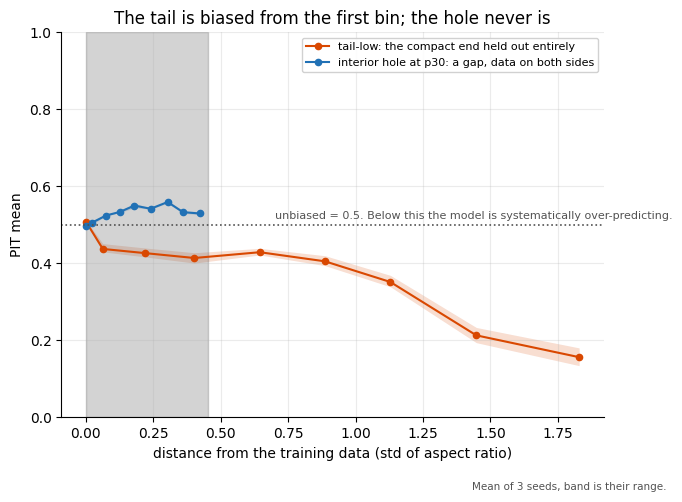

In [235]:
def pit_by_distance(split, seed):
    """PIT mean per distance bin, for one seed.

    Same shape as coverage_by_distance in the previous cell: same
    distance_bins call, same in-region anchor at distance 0, so the two
    figures share bins and can be read side by side. Recomputed here rather
    than read from calibration_bins.csv, which only covers seed 0.
    """
    df = points_for(split, seed)
    out = df[df['region'] == 'out']
    rows, masks = distance_bins(out['distance'].to_numpy(), N_DISTANCE_BINS)
    per_bin = [
        float(pit_values(
            out['y_true'].to_numpy()[m],
            out['mean'].to_numpy()[m],
            out['total_variance'].to_numpy()[m],
        ).mean())
        for m in masks
    ]
    anchor = df[df['region'] == 'in']
    in_region = float(
        pit_values(anchor['y_true'], anchor['mean'], anchor['total_variance']).mean()
    )
    return [0.0, *[r['d_median'] for r in rows]], [in_region, *per_bin]


fig, ax = plt.subplots(figsize=(FIG_WIDTH, 5))

SERIES = {
    'tail': ('tail-low: the compact end held out entirely', COLOR_TAIL),
    'hole': ('interior hole at p30: a gap, data on both sides', COLOR_HOLE),
}

curves = {}

for name, (label, color) in SERIES.items():
    per_seed = [pit_by_distance(name, s) for s in SEEDS]
    d = per_seed[0][0]
    pit = band(ax, d, [c for _, c in per_seed], color)
    ax.plot(d, pit, 'o-', color=color, markersize=4.5, label=label)
    curves[name] = (d, pit)

ax.axhline(0.5, color=COLOR_NEUTRAL, linestyle=':', linewidth=1.2)
ax.annotate(
    'unbiased = 0.5. Below this the model is systematically over-predicting.',
    (0.7, 0.51),
    fontsize=8,
    color=COLOR_NEUTRAL,
    ha='left',
    va='bottom',
)

overlap = max(b['d_hi'] for b in calibration['hole']['bins'])
ax.axvspan(0, overlap, color=COLOR_NEUTRAL, alpha=0.25)

ax.set_ylim(0, 1)
ax.set_xlabel('distance from the training data (std of aspect ratio)')
ax.set_ylabel('PIT mean')
ax.set_title('The tail is biased from the first bin; the hole never is')
ax.legend(fontsize=8, loc='upper right', framealpha=0.9)

fig.text(
    0.99,
    -0.02,
    f'Mean of {len(SEEDS)} seeds, band is their range.',
    ha='right',
    va='top',
    fontsize=7.5,
    color=COLOR_NEUTRAL,
)

keep(fig, 'pit_distance')

## Figure 4: calibration at every confidence level

Figure 3 fixes the confidence level at 90% and varies distance. This does the
opposite: it sweeps the level and separates in-region from out-of-region, so a
reader can check the failure is not an artifact of one arbitrary choice.

The diagonal is perfect calibration. Above it the model is conservative, below
it overconfident. Random is the control and should sit on the diagonal in both
regions, which is what makes the other two panels readable as shift rather than
as a quirk of the diagnostic.


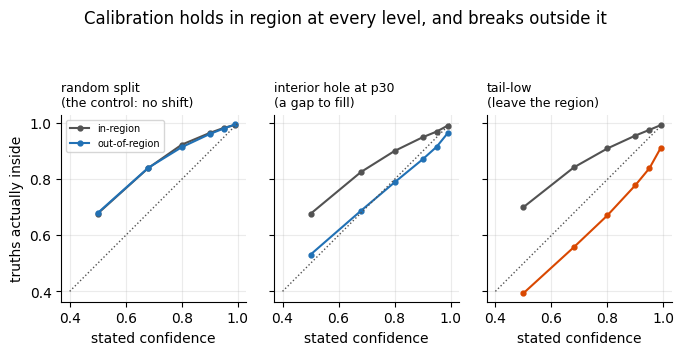

In [236]:
fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH, 3.8), sharex=True, sharey=True)

TITLES = {
    'random': 'random split\n(the control: no shift)',
    'hole': 'interior hole at p30\n(a gap to fill)',
    'tail': 'tail-low\n(leave the region)',
}

for ax, (name, title) in zip(axes, TITLES.items(), strict=True):
    for region, color, style in (
        ('in-region', COLOR_NEUTRAL, '-'),
        ('out-of-region', COLOR_TAIL if name == 'tail' else COLOR_HOLE, '-'),
    ):
        measured = [calibration[name]['sets'][region]['coverage'][f'{lv:g}'] for lv in LEVELS]
        ax.plot(LEVELS, measured, style, marker='o', markersize=3.5, color=color, label=region)

    ax.plot([0.4, 1.0], [0.4, 1.0], ':', color=COLOR_NEUTRAL, linewidth=1)
    ax.set_title(title, fontsize=9, loc='left')
    ax.set_xlabel('stated confidence')
    ax.set_aspect('equal')

axes[0].set_ylabel('truths actually inside')
axes[0].legend(fontsize=7, loc='upper left')
fig.suptitle('Calibration holds in region at every level, and breaks outside it')
fig.tight_layout()

keep(fig, 'coverage_nominal')

## Figure 5: what kind of wrong

Coverage says how badly the intervals are calibrated. It cannot say which way,
and two very different faults produce the same coverage number: intervals too
narrow but centred correctly, or intervals fine but the prediction itself
biased. They need different fixes, so the distinction is worth a figure.

PIT is where each truth landed inside its own predicted distribution, on a 0 to
1 scale. A calibrated model spreads them evenly, so the bars sit on the dotted
line. Piling up at both ends means intervals too narrow. **Leaning to one side
means the mean is biased**, and widening the error bars would not help.

**The finding, and it is the one coverage missed.** The tail's out-of-region
panel leans hard left, mean PIT 0.348 against 0.51 everywhere else. The truth
keeps landing below the prediction, so the model systematically over-predicts
edge rotational transform at the compact edge. The hole shows nothing like it,
which separates the two conditions a second time.

Aggregate only, per decision log 7.1. Binned by distance these bars would rest
on about 60 points each and jump around from sampling noise alone.


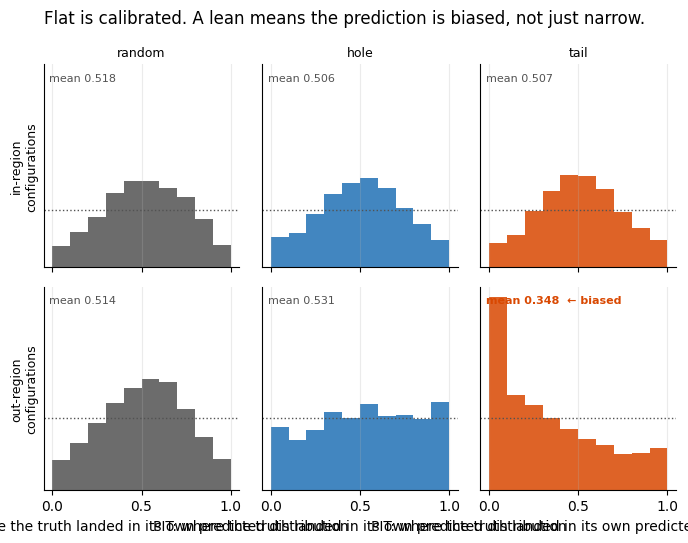

In [237]:
fig, axes = plt.subplots(2, 3, figsize=(FIG_WIDTH, 5.5), sharex=True, sharey=True)

COLUMNS = ['random', 'hole', 'tail']
bins = np.linspace(0, 1, 11)

for col, name in enumerate(COLUMNS):
    for row, region in enumerate(['in', 'out']):
        ax = axes[row, col]
        sel = pit_points[(pit_points['split'] == name) & (pit_points['region'] == region)]
        color = COLOR_TAIL if name == 'tail' else COLOR_HOLE
        if name == 'random':
            color = COLOR_NEUTRAL

        ax.hist(sel['pit'], bins=bins, color=color, alpha=0.85)
        ax.axhline(len(sel) / 10, color=COLOR_NEUTRAL, linestyle=':', linewidth=1)

        mean_pit = sel['pit'].mean()
        biased = abs(mean_pit - 0.5) > 0.05
        ax.annotate(
            f'mean {mean_pit:.3f}' + ('  ← biased' if biased else ''),
            (0.03, 0.92),
            xycoords='axes fraction',
            fontsize=8,
            color=COLOR_TAIL if biased else COLOR_NEUTRAL,
            fontweight='bold' if biased else 'normal',
        )
        if row == 0:
            ax.set_title(name, fontsize=9)
        if col == 0:
            ax.set_ylabel(f'{region}-region\nconfigurations', fontsize=9)
        ax.set_yticks([])

for ax in axes[1]:
    ax.set_xlabel('PIT: where the truth landed in its own predicted distribution')

fig.suptitle('Flat is calibrated. A lean means the prediction is biased, not just narrow.')
fig.tight_layout()

keep(fig, 'pit_histograms')

## Figure 6: the standard fix makes it worse

Closes the obvious objection to Figures 3 to 5. "The model is overconfident at
the compact edge" invites "so recalibrate it", and this answers with a
measurement rather than an argument.

**Variance scaling**, one scalar per split, `sigma -> s * sigma`. Under Gaussian
NLL the minimiser is closed form, `s = sqrt(mean(z^2))`. **Fitted on a
held-out half of the in-region slice**, because calibrating on out-of-region
points would assume access to exactly the labels the whole premise says are
unavailable. Every number plotted comes from the other half and from the
untouched out-of-region sets.

**Read the arrows against the dashed target line.** The result needs all three
parts and any one alone is misleading:

1. **It works where it is fitted.** Every in-region arrow moves toward the
   target. So the method is not broken, which is what makes the rest readable.
2. **It transfers correctly when there is no shift.** The random split's
   out-of-region arrow also moves toward the target. **That split is the
   control**: a correction that degraded everything would prove nothing.
3. **It actively harms calibration under shift.** The hole and tail
   out-of-region arrows move *away*. At the compact edge a stated 90% interval
   held 78% of the truth and now holds **67%**.

**Two independent confirmations, neither plotted here.** CRPS rises out of
region on both shifted splits while falling everywhere in region, and CRPS is a
proper scoring rule, so this is not an artifact of the ratio. And PIT barely
moves, 0.348 to 0.333 at the tail, because **a variance scale cannot fix a mean
bias**, which reconfirms Figure 5 by a different route.

**In-region coverage lands slightly above nominal after correction**, 0.910
to 0.920 against 0.9. The scalar is fitted by NLL, not by matching coverage at
one level, so it balances the whole distribution rather than pinning a single
quantile. Not a residual failure.

**Reporting only.** Nothing here feeds the deferral rule, and the deferral
ranking is provably untouched: a positive scalar cannot reorder points, verified
on all three splits rather than assumed. No headline number changes.


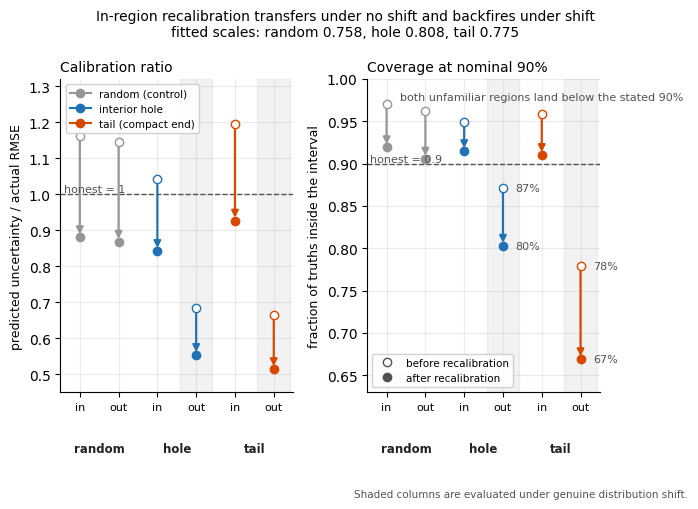

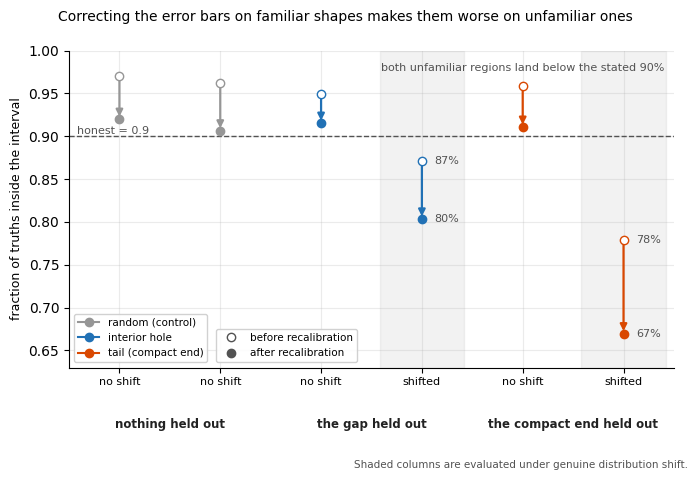

In [238]:
from matplotlib.lines import Line2D

recal = load_results('recalibration')['results']

COLOR_BY_SPLIT = {'random': COLOR_TRAIN, 'hole': COLOR_HOLE, 'tail': COLOR_TAIL}
COMBOS = [(s, r) for s in ('random', 'hole', 'tail') for r in ('in', 'out')]
# The two columns where the evaluation set is genuinely shifted. Shaded so the
# eye finds them without having to compare six pairs of arrow lengths.
SHIFTED = [i for i, (s, r) in enumerate(COMBOS) if r == 'out' and s != 'random']

PANELS = {
    'ratio': (1.0, 'predicted uncertainty / actual RMSE', 'Calibration ratio'),
    'coverage': (0.9, 'fraction of truths inside the interval', 'Coverage at nominal 90%'),
}

# Two tiers, not one two-word label. "gap familiar" read as a claim about the
# gap itself ("the gap is familiar"), when it names an experiment (which
# region that model had held out) crossed with a slice of it. And "seen" /
# "unseen" turned out to be the wrong axis entirely: the control's held-back
# column was "unseen" too, yet behaved like the familiar ones, because what
# actually separates the six columns is whether the evaluation set is
# genuinely shifted, not whether it was held back from training.
TECHNICAL_COLUMNS = ['in', 'out', 'in', 'out', 'in', 'out']
TECHNICAL_GROUPS = ['random', 'hole', 'tail']
# The README reaches this figure before it has introduced "hole", "tail" or
# "in/out of region", so its copy gets labels that need no prior vocabulary.
PLAIN_COLUMNS = ['no shift', 'no shift', 'no shift', 'shifted', 'no shift', 'shifted']
PLAIN_GROUPS = ['nothing held out', 'the gap held out', 'the compact end held out']

# Two legends, not one merged list: colour answers "which split" and marker
# shape answers "before or after", and those are independent questions. A
# reader only needs the second one once they already know the first from the
# x-axis labels or the colour legend, so keeping them apart lets each stay
# short.
SPLIT_LEGEND_LABELS = {
    'random': 'random (control)',
    'hole': 'interior hole',
    'tail': 'tail (compact end)',
}
SPLIT_HANDLES = [
    Line2D(
        [0], [0], color=COLOR_BY_SPLIT[s], marker='o', markersize=6, linestyle='-',
        label=SPLIT_LEGEND_LABELS[s],
    )
    for s in ('random', 'hole', 'tail')
]
MARKER_HANDLES = [
    Line2D(
        [0], [0], marker='o', color=COLOR_NEUTRAL, markerfacecolor='white',
        markersize=6, linestyle='none', label='before recalibration',
    ),
    Line2D(
        [0], [0], marker='o', color=COLOR_NEUTRAL, markerfacecolor=COLOR_NEUTRAL,
        markersize=6, linestyle='none', label='after recalibration',
    ),
]

# What the shading means doesn't fit either legend, colour and marker shape are
# both already spoken for, so it stays a short caption instead of a third
# legend entry.
SHIFT_CAPTION = 'Shaded columns are evaluated under genuine distribution shift.'


def draw_panel(ax, key, column_labels=TECHNICAL_COLUMNS, group_labels=TECHNICAL_GROUPS):
    """One before/after panel. Shared by the notebook's two-panel version and the
    README's coverage-only cut, so the two cannot drift apart."""
    target, ylabel, title = PANELS[key]

    for x in SHIFTED:
        ax.axvspan(x - 0.42, x + 0.42, color=COLOR_NEUTRAL, alpha=0.07, zorder=0)

    for x, (split, region) in enumerate(COMBOS):
        before = recal[split][region]['before'][key]
        after = recal[split][region]['after'][key]
        color = COLOR_BY_SPLIT[split]

        # The arrow carries the direction; open marker is before, filled is after.
        ax.annotate(
            '',
            xy=(x, after),
            xytext=(x, before),
            arrowprops={'arrowstyle': '-|>', 'color': color, 'lw': 1.6},
        )
        ax.plot(x, before, 'o', color=color, markerfacecolor='white', markersize=6, zorder=3)
        ax.plot(x, after, 'o', color=color, markersize=6, zorder=3)

    ax.axhline(target, color=COLOR_NEUTRAL, linestyle='--', linewidth=1)
    ax.annotate(
        f'honest = {target:g}',
        (-0.42, target),
        fontsize=8,
        color=COLOR_NEUTRAL,
        va='bottom',
        ha='left',
    )

    ax.set_xticks(range(len(COMBOS)))
    ax.set_xticklabels(column_labels, fontsize=8)
    # Group label spans each pair of columns, in axes-fraction y so it sits a
    # fixed distance below the tick labels regardless of the panel's own
    # y-range (the two panels here use different ones).
    group_trans = ax.get_xaxis_transform()
    for i, group in enumerate(group_labels):
        ax.text(
            i * 2 + 0.5, -0.16, group, transform=group_trans,
            ha='center', va='top', fontsize=8.5, fontweight='bold', color='#222222',
        )
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, loc='left')
    ax.set_xlim(-0.5, len(COMBOS) - 0.5)


def annotate_shift_gap(ax):
    """Both out-of-region columns land below the stated 90%, not only the
    compact end. A single orange callout on the tail alone implied the gap
    mostly escaped this, and it does not. A number sits next to each marker
    directly (before next to the open circle, after next to the filled one)
    rather than one floating label with an arrow."""
    hole_before = recal['hole']['out']['before']['coverage']
    hole_after = recal['hole']['out']['after']['coverage']
    tail_before = recal['tail']['out']['before']['coverage']
    tail_after = recal['tail']['out']['after']['coverage']

    for x, value in ((3, hole_before), (5, tail_before)):
        ax.annotate(
            f'{value:.0%}',
            xy=(x, value),
            textcoords='offset points',
            xytext=(9, 0),
            va='center',
            ha='left',
            fontsize=8,
            color=COLOR_NEUTRAL,
        )
    for x, value in ((3, hole_after), (5, tail_after)):
        ax.annotate(
            f'{value:.0%}',
            xy=(x, value),
            textcoords='offset points',
            xytext=(9, 0),
            va='center',
            ha='left',
            fontsize=8,
            color=COLOR_NEUTRAL,
        )
    ax.annotate(
        'both unfamiliar regions land below the stated 90%',
        xy=(4, 0.985),
        fontsize=8,
        color=COLOR_NEUTRAL,
        ha='center',
        va='top',
    )


# Two panels, for the notebook. One legend per panel rather than both on one:
# the ratio panel's top-left is clear, the coverage panel's bottom-left is
# clear, and neither panel had room for both boxes without them overlapping.
fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, 4.8))
for ax, key in zip(axes, PANELS, strict=True):
    draw_panel(ax, key)

axes[0].set_ylim(0.45, 1.32)
axes[1].set_ylim(0.63, 1.00)

axes[0].legend(handles=SPLIT_HANDLES, loc='upper left', fontsize=7.5, framealpha=0.9)
axes[1].legend(handles=MARKER_HANDLES, loc='lower left', fontsize=7.5, framealpha=0.9)
annotate_shift_gap(axes[1])

scales = ', '.join(f'{s} {recal[s]["scale"]:.3f}' for s in ('random', 'hole', 'tail'))
fig.suptitle(
    'In-region recalibration transfers under no shift and backfires under shift'
    f'\nfitted scales: {scales}',
    fontsize=10,
)
fig.text(0.99, -0.02, SHIFT_CAPTION, ha='right', va='top', fontsize=7.5, color=COLOR_NEUTRAL)
fig.tight_layout()

keep(fig, 'recalibration')

# Coverage only, for the README. Finding 2 there is written entirely in coverage
# terms, and the calibration-ratio panel introduces a quantity that page never
# defines. Same draw_panel, so the two figures cannot disagree. Only one axes
# here, so both legends have to share it, stacked in its one clear corner
# rather than the two separate corners the two-panel version uses.
fig, ax = plt.subplots(figsize=(FIG_WIDTH, 4.5))
draw_panel(ax, 'coverage', column_labels=PLAIN_COLUMNS, group_labels=PLAIN_GROUPS)
ax.set_ylim(0.63, 1.00)
# draw_panel sets the LEFT-aligned title text specifically; set_title('') alone
# clears the centred one and leaves this one on screen, a bug this caught.
ax.set_title('', loc='left')

split_legend = ax.legend(
    handles=SPLIT_HANDLES, loc='lower left', bbox_to_anchor=(0.0, 0.0),
    fontsize=7.5, framealpha=0.9,
)
ax.add_artist(split_legend)
ax.legend(
    handles=MARKER_HANDLES, loc='lower left', bbox_to_anchor=(0.235, 0.0),
    fontsize=7.5, framealpha=0.9,
)
annotate_shift_gap(ax)

fig.suptitle(
    'Correcting the error bars on familiar shapes makes them worse on unfamiliar ones',
    fontsize=10,
)
fig.text(0.99, -0.02, SHIFT_CAPTION, ha='right', va='top', fontsize=7.5, color=COLOR_NEUTRAL)
fig.tight_layout()

keep(fig, 'recalibration_coverage')

## Figure 7: the deferral curve

Deliverable two, and the answer to the obvious objection to Figures 3 to 6. If
the intervals cannot be trusted as intervals off-distribution, is the
uncertainty worth anything at all?

Yes, because deferral does not need the interval. It needs the **ordering**.
Rank the held-out shapes by predicted uncertainty, send the worst fraction to
VMEC++, keep the surrogate's answer for the rest. The y axis scores the whole
hybrid system, with deferred points credited exact.

**The finding.** Solving the worst 20% by uncertainty cuts the error by 41%,
against 20% for a random 20%. Halving the error takes 27% of designs solved
rather than 50%. The signal captures 63% of the headroom between the random
floor and a perfect ranking. Those numbers hold on either axis: 40.8% and 63%
on MAE, 41.0% and 63% on CRPS.

**The pairing with Figures 3 to 6 is the honest summary of the project:** the
intervals are badly miscalibrated at the compact edge, and the ranking still
works there. A signal can be useless as an absolute interval and good at
ordering.

**Total beat both epistemic and aleatoric in all 3 training runs on this split,
and aleatoric beat epistemic in all 3 as well.** The bands in the plot below
show how much the curves shift between runs, not this comparison: they
overlap, but the ordering held every time.

### The `SCORE` toggle, and why MAE is the default

The y axis is set by `SCORE` in the cell below. `'mae'` is the deliverable,
`'crps'` the supporting check. **This reverses the original choice, and the
reversal is dated 2026-09-04.**

**What the original decision said** (decision log 8.3, the deferral curve's y
axis). CRPS was the deliverable because this is the one figure where the whole
predictive distribution is under test: MAE and RMSE score a mean-variance
ensemble *identically to a plain point predictor with the same means*, so an MAE
axis is blind to whether the variance head does anything, while the deferral
decision is driven entirely by that head.

**Why it no longer holds.** That argument was made before Figures 3 to 6
existed. They test the predictive distribution directly, and the variance-head
injection check tests it harder than any deferral curve can, by recovering a
known injected sigma. CRPS has no unique job left here.

**What decides it the other way.** For a Gaussian, CRPS scales with sigma.
Ranking by sigma therefore strips high-CRPS points partly *by construction*,
not only because those points were genuinely wrong, so the margin over the
random floor is flattered by the ranking signal living inside the metric. MAE
never touches the predicted variance, so a win there means the uncertainty
located genuinely wrong predictions. That is the sharper claim, and the one the
README makes in words.

**MAE also fixes the random floor analytically.** The curve is a cumulative mean
with deferred points credited zero, so it is linear in the retained fraction and
random deferral at rate r lands at exactly (1-r) of the baseline. "Spend 20% of
the budget, remove 20% of the error" is then exact rather than empirical. Under
CRPS the floor is a curve and that reading is only approximate.

**Nothing in the headline moves**, which is what makes the swap safe to report
rather than a change of result. CRPS stays as the check that says the finding
also holds under a proper scoring rule.

Flipping the toggle also swaps the oracle's ranking signal and the saved
filename. The oracle must rank by whichever score is plotted or it stops being a
ceiling, and the separate filename stops an MAE run from overwriting the
committed CRPS figure.

Deferred points are credited the exact solver value, so this assumes the
solver always succeeds. Figure 8 below measures how often that assumption
holds.


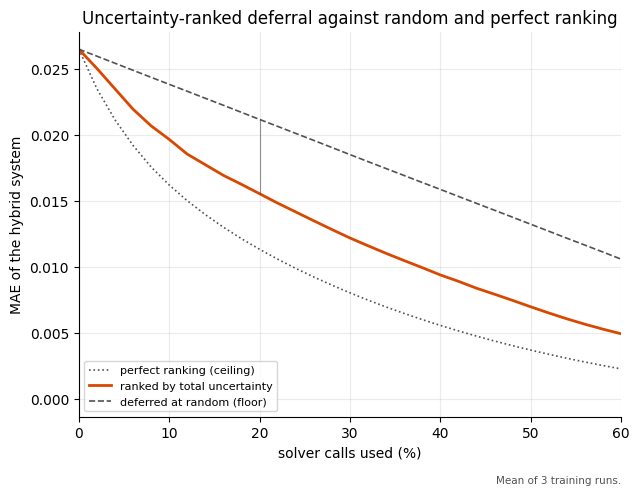

In [239]:
# Toggle. 'mae' is the deliverable and the default; 'crps' is the supporting
# check described in the markdown above. Changing this changes the y axis, the
# oracle's ranking signal and the saved filename together, which is the point:
# any one of the three left behind would produce a quietly wrong figure.
SCORE = 'mae'

RATES = np.linspace(0.0, 1.0, 51)


def absolute_error(y_true, mean, variance):
    """MAE's per-point score. Takes variance it does not use, to match the CRPS
    signature, so the toggle swaps one callable and nothing else."""
    del variance
    return np.abs(np.asarray(y_true) - np.asarray(mean))


SCORERS = {
    'crps': (crps_gaussian, 'CRPS', 'Miscalibrated intervals, and the ranking still works'),
    'mae': (
        absolute_error,
        'MAE',
        'Uncertainty-ranked deferral against random and perfect ranking',
    ),
}
score_fn, score_label, score_title = SCORERS[SCORE]


def curves_for(split, seed, region='out'):
    """The five deferral curves for one seed, using the same helper as the script.

    metrics.deferral_curve is shared with scripts/deferral.py and
    scripts/seed_spread.py on purpose: two independent implementations of a
    cumulative-sum index is exactly how the aggregation bug happened.

    The oracle ranks by the plotted score itself, whichever that is. Under MAE an
    oracle that still ranked by CRPS would not bound the curve being drawn, and
    the two signal curves could cross their own ceiling.
    """
    df = points_for(split, seed)
    df = df[df['region'] == region]
    score = score_fn(df['y_true'], df['mean'], df['total_variance'])
    rng = np.random.default_rng(seed)
    return {
        'oracle': deferral_curve(score, score, RATES),
        'total': deferral_curve(score, df['total_variance'], RATES),
        # Reinstated 2026-09-03. The deferral spec cut this one, predicting it
        # would land on the random floor because aleatoric would sit at the
        # numerical floor. Step 2 measured aleatoric at 0.01194, larger than
        # epistemic, and it is model misfit rather than label noise. Misfit is a
        # near-direct statement about local difficulty, so it ranks well.
        'aleatoric': deferral_curve(score, df['aleatoric_variance'], RATES),
        'epistemic': deferral_curve(score, df['epistemic_variance'], RATES),
        'random': np.mean(
            [deferral_curve(score, rng.permutation(len(score)), RATES) for _ in range(50)],
            axis=0,
        ),
    }


per_seed = [curves_for('tail', s) for s in SEEDS]

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 5))

# Only total-ranked is drawn. Aleatoric and epistemic land within a few percent
# of it, so three near-identical lines cost the reader attention without changing
# the conclusion. curves_for still computes them; the comparison between the three
# is stated in the markdown above and in results/seed_spread.json.
RANKINGS = {
    'oracle': ('perfect ranking (ceiling)', COLOR_NEUTRAL, ':', 1.2),
    'total': ('ranked by total uncertainty', COLOR_TAIL, '-', 2.0),
    'random': ('deferred at random (floor)', COLOR_NEUTRAL, '--', 1.2),
}

x = RATES * 100
means = {}

for name, (label, color, style, width) in RANKINGS.items():
    stack = [c[name] for c in per_seed]
    # No bands. A marginal band cannot show a paired, within-run comparison,
    # and overlapping bands read as "these are the same," which is wrong.
    mean = np.mean(stack, axis=0)
    means[name] = mean
    ax.plot(x, mean, style, color=color, linewidth=width, label=label)

# Computed from the plotted curves rather than read from deferral.json, so the
# annotation follows the toggle and matches the seed-averaged lines. The JSON
# holds seed 0 and CRPS only, so reading it here would caption a different curve
# from the one drawn.
at_20 = {k: float(np.interp(0.2, RATES, v)) for k, v in means.items()}
none = float(means['total'][0])

# Cross-check seed 0 against the committed artifact for whichever score is
# plotted. This used to run on the CRPS path only, which meant the figure the
# README publishes was verified against nothing. scripts/deferral.py writes
# deferral.json for CRPS and deferral_mae.json for MAE.
artifact = load_results('deferral' if SCORE == 'crps' else f'deferral_{SCORE}')['results']
seed0_at_20 = float(np.interp(0.2, RATES, per_seed[0]['total']))
assert abs(seed0_at_20 - artifact['out']['rankings']['total']['score_at']['0.2']) < 1e-12

ax.annotate(
    f'Mean of {len(SEEDS)} training runs.',
    xy=(1.0, 0.0),
    xycoords='axes fraction',
    xytext=(0, -42),
    textcoords='offset points',
    ha='right',
    va='top',
    fontsize=7.5,
    color=COLOR_NEUTRAL,
)

ax.plot([20, 20], [at_20['total'], at_20['random']], color=COLOR_NEUTRAL, lw=0.8, alpha=0.6)

ax.set_xlim(0, 60)
ax.set_xlabel('solver calls used (%)')
ax.set_ylabel(f'{score_label} of the hybrid system')
ax.set_title(score_title)
# Lower left: the only corner no curve enters, and it frees the top right for
# the annotation that carries the figure's number.
ax.legend(fontsize=8, loc='lower left')

# Separate filename per score, so flipping the toggle and saving cannot
# overwrite the committed CRPS deliverable with a different metric.
keep(fig, 'deferral_curve' if SCORE == 'crps' else 'deferral_curve_mae')

## Figure 8: the fallback does not always answer

The caveat Figure 7 needs. The deferral curve credits every deferred shape with
the exact solver value, which assumes VMEC++ always converges. It does not, and
the assumption is weakest exactly where deferral sends the most work.

**Aspect ratio is null on every failed row**, since it is computed *from* the
solved equilibrium. So it is predicted from the 80 boundary coefficients out of
fold, R2 0.9876 and Spearman 0.990, with **the same instrument applied to both
groups** so a difference in failure rate cannot be prediction error.

**Left panel: the apparent finding.** Failure rate is a U, 42% at the compact
end and 39% at the extended end against 4% in the middle. Below the tail cutoff
it reads 31.2% against 11.6% above, a **2.68x**.

**Right panel: the confound, and it is the real finding.** Holding the generator
fixed, **every solver failure is a `vmec`-pathway row**, and within `vmec` the
compact penalty is only **1.11x**. The compact region is 82% `vmec`-proposed
against 34% elsewhere, so sorting by compactness was sorting by generator.

**The defensible sentence: solver reliability is a property of the proposal
process, not of the geometry.** That is also the more useful one, because it
says what would change the risk: swap the generator, not the region.

**Do not read `desc` at 0.00% across 17,671 rows as DESC never failing.** Too
clean. More likely the flag is set differently per pathway, or that pipeline ran
a forward model internally and emitted only converged rows.

**None of this makes Figure 7 wrong on its own terms.** Every shape in the
pool solved, by construction. This is about **deployment**: crediting only the
roughly 69% that would solve turns the 41% CRPS cut at 20% deferral into about
28%. Deferral still beats random by the same margin, since random deferral draws
from the same population and eats the same failure rate. Only the level moves.


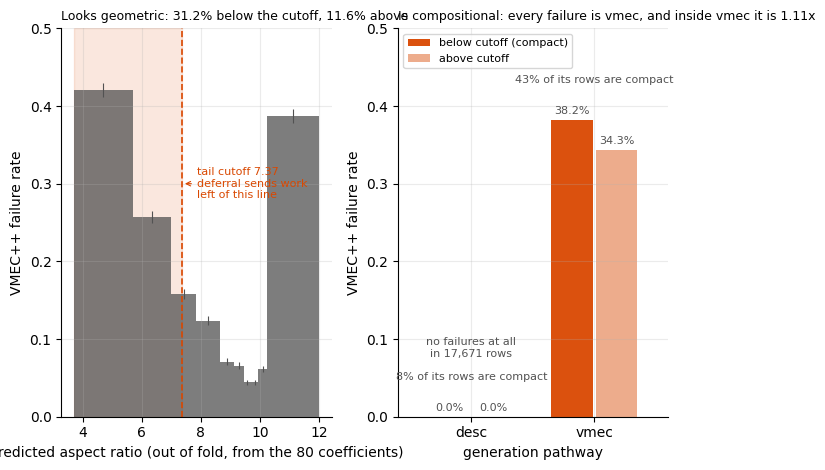

In [240]:
solver = load_results('solver_failures')['results']
bins = pd.DataFrame(solver['bins'])
cutoff = solver['cutoff']

fig, (ax_u, ax_path) = plt.subplots(1, 2, figsize=(FIG_WIDTH, 4.8))

# Left: the U. Bars span their actual bin width, so the wide end bins are not
# drawn as if they were as narrow as the dense middle ones.
ax_u.bar(
    bins['a_lo'],
    bins['rate'],
    width=bins['a_hi'] - bins['a_lo'],
    align='edge',
    color=COLOR_NEUTRAL,
    alpha=0.75,
    yerr=bins['stderr'],
    error_kw={'lw': 0.8, 'ecolor': COLOR_NEUTRAL},
)
ax_u.axvspan(bins['a_lo'].min(), cutoff, color=COLOR_TAIL, alpha=0.13, zorder=0)
ax_u.axvline(cutoff, color=COLOR_TAIL, linestyle='--', linewidth=1.2)
ax_u.annotate(
    f'tail cutoff {cutoff:.2f}\ndeferral sends work\nleft of this line',
    xy=(cutoff, 0.30),
    xytext=(cutoff + 0.5, 0.30),
    fontsize=8,
    color=COLOR_TAIL,
    va='center',
    arrowprops={'arrowstyle': '->', 'color': COLOR_TAIL, 'lw': 0.8},
)
ax_u.set_ylim(0, 0.50)
ax_u.set_xlabel('predicted aspect ratio (out of fold, from the 80 coefficients)')
ax_u.set_ylabel('VMEC++ failure rate')
ax_u.set_title(
    f'Looks geometric: {solver["below_cutoff"]["rate"]:.1%} below the cutoff, '
    f'{solver["above_cutoff"]["rate"]:.1%} above',
    fontsize=9,
    loc='left',
)

# Right: the same comparison inside each generator, which is what dissolves it.
confound = pd.DataFrame(solver['pathway_confound'])
x = np.arange(len(confound))
for offset, key, label, alpha in [
    (-0.18, 'rate_below', 'below cutoff (compact)', 0.95),
    (0.18, 'rate_above', 'above cutoff', 0.45),
]:
    ax_path.bar(x + offset, confound[key], width=0.34, color=COLOR_TAIL, alpha=alpha, label=label)
    for xi, rate in zip(x, confound[key], strict=True):
        ax_path.annotate(
            f'{rate:.1%}',
            (xi + offset, rate + 0.008),
            ha='center',
            fontsize=8,
            color=COLOR_NEUTRAL,
        )

for i, row in confound.iterrows():
    # Zero-height bars are invisible, so desc needs its count said in words or
    # the panel reads as missing data rather than as the finding.
    note = f'{row["share_below_cutoff"]:.0%} of its rows are compact'
    if row['rate_below'] == 0 and row['rate_above'] == 0:
        note = f'no failures at all\nin {row["n"]:,} rows\n\n{note}'
    ax_path.annotate(
        note,
        (i, max(row['rate_below'], row['rate_above']) + 0.045),
        ha='center',
        va='bottom',
        fontsize=8,
        color=COLOR_NEUTRAL,
    )

ax_path.set_xticks(x)
ax_path.set_xticklabels(confound['pathway'])
ax_path.set_xlim(-0.6, len(confound) - 0.4)
ax_path.set_ylim(0, 0.50)
ax_path.set_xlabel('generation pathway')
ax_path.set_ylabel('VMEC++ failure rate')
ax_path.legend(fontsize=8, loc='upper left')
vmec_risk = confound.loc[confound['pathway'] == 'vmec', 'relative_risk'].item()
ax_path.set_title(
    f'Is compositional: every failure is vmec, and inside vmec it is {vmec_risk:.2f}x',
    fontsize=9,
    loc='left',
)

fig.tight_layout()

keep(fig, 'solver_failures')


## Figure 9: the decomposition earns its names

Step 8, the validation run. Everything above measures whether the uncertainty
is calibrated and whether it ranks. Both can be true while the split into two
terms is meaningless, because a signal that ranks well has said nothing about
which half of it is ignorance and which is noise.

The test is what the two names actually claim. **Epistemic is ignorance, so it
must shrink as data grows. Aleatoric is noise, so it must not.**

On clean targets that second half has no content, because there the
aleatoric term is the model's own misfit and misfit does shrink with data. So
the sweep runs twice, once clean and once with Gaussian noise of a known
σ = 0.020 added to the training targets. The right panel subtracts the two in
quadrature, within seed, which pulls the injected component back out.

**The finding.** Left: epistemic falls monotonically in both conditions. Right:
the reducible part falls from 0.040 to 0.011 over a seventeenfold increase in
data, while the recovered injected part converges on 0.020 from above, reaching
0.0208 against a true 0.020.

It converges rather than sitting flat, and the mechanism is worth stating rather
than softening the sentence. Quadrature subtraction credits the clean run's
misfit to the noisy run, but noisy training fits worse, so the subtraction
over-attributes and every rung lands above the true sigma. Both misfits shrink
with N, so the excess shrinks too. That makes the convergence evidence for the
decomposition rather than noise against it.

No exponent is fitted, per decision log 6.3. Five rungs at three seeds show a
shape and nothing finer.


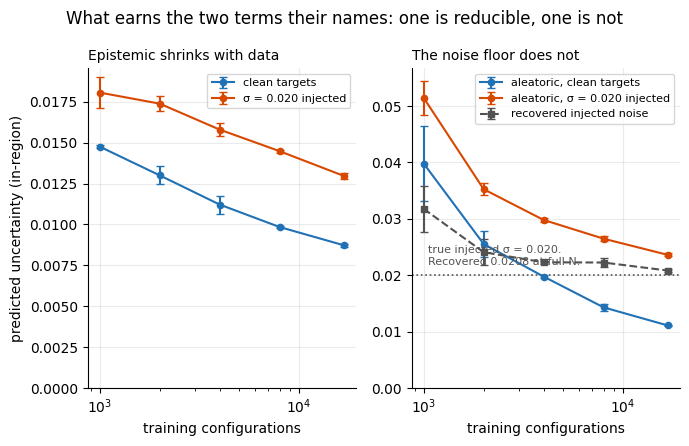

In [241]:
fig, (ax_epi, ax_ale) = plt.subplots(1, 2, figsize=(FIG_WIDTH, 4.5))

sizes = sorted({c['n_train'] for c in sweep_cells})
CONDITIONS = {0.0: ('clean targets', COLOR_HOLE), 0.02: ('σ = 0.020 injected', COLOR_TAIL)}


def cells_at(sigma, n):
    rows = [c for c in sweep_cells if c['sigma'] == sigma and c['n_train'] == n]
    return sorted(rows, key=lambda c: c['seed'])


def spread(sigma, n, term):
    values = [c['in_region'][term] for c in cells_at(sigma, n)]
    return np.mean(values), np.std(values)


for sigma, (label, color) in CONDITIONS.items():
    stats = [spread(sigma, n, 'epistemic') for n in sizes]
    ax_epi.errorbar(
        sizes,
        [m for m, _ in stats],
        yerr=[s for _, s in stats],
        fmt='o-',
        color=color,
        markersize=4.5,
        capsize=3,
        label=label,
    )

    stats = [spread(sigma, n, 'aleatoric') for n in sizes]
    ax_ale.errorbar(
        sizes,
        [m for m, _ in stats],
        yerr=[s for _, s in stats],
        fmt='o-',
        color=color,
        markersize=4.5,
        capsize=3,
        label=f'aleatoric, {label}',
    )

# Quadrature subtraction within seed: sqrt(noisy^2 - clean^2) recovers what was
# injected. This is the panel's actual claim, the two curves above are its inputs.
recovered = []
for n in sizes:
    pairs = zip(cells_at(0.0, n), cells_at(0.02, n), strict=True)
    per_seed = [
        np.sqrt(max(b['in_region']['aleatoric'] ** 2 - a['in_region']['aleatoric'] ** 2, 0.0))
        for a, b in pairs
    ]
    recovered.append((np.mean(per_seed), np.std(per_seed)))

ax_ale.errorbar(
    sizes,
    [m for m, _ in recovered],
    yerr=[s for _, s in recovered],
    fmt='s--',
    color=COLOR_NEUTRAL,
    markersize=5,
    capsize=3,
    label='recovered injected noise',
)
ax_ale.axhline(0.020, color=COLOR_NEUTRAL, linestyle=':', linewidth=1.2)
ax_ale.annotate(
    f'true injected σ = 0.020.\nRecovered {recovered[-1][0]:.4f} at full N.',
    (sizes[0] * 1.05, 0.0215),
    fontsize=8,
    color=COLOR_NEUTRAL,
    va='bottom',
)

for ax, title in ((ax_epi, 'Epistemic shrinks with data'), (ax_ale, 'The noise floor does not')):
    ax.set_xscale('log')
    ax.set_xlabel('training configurations')
    ax.set_title(title, fontsize=10, loc='left')
    ax.legend(fontsize=8)

ax_epi.set_ylabel('predicted uncertainty (in-region)')
ax_epi.set_ylim(0, None)
ax_ale.set_ylim(0, None)
fig.suptitle('What earns the two terms their names: one is reducible, one is not')
fig.tight_layout()

keep(fig, 'n_sweep')

## Figure 10: more of the same data does not buy extrapolation

The N-sweep's second result, and the one with the most direct operational
meaning. Figure 9 asked whether the two uncertainty terms behave as their names
claim. This asks what happens to the extrapolation gap itself as the training
set grows.

Each point is the ratio of out-of-region to in-region RMSE, averaged over three
seeds, with the seed spread as error bars. It climbs from 1.71 to 3.39 as
training data grows seventeenfold. In-region error falls 67% across the sweep;
out-of-region falls only 29%.

**State this narrowly or it overreaches.** Subsampling happens *within* the
training region, so "more data" here means more of the same distribution, and
more of a distribution cannot populate a region it excludes. The defensible
claim is that **scaling the existing dataset does not buy extrapolation
reliability**, so the answer is targeted sampling in the sparse region, or
deferral. That is also what the two 2026 compact-stellarator papers are doing.

**A third claim was drafted and withdrawn before it reached this figure.**
"Out-of-region calibration degrades as N grows" came from reading seed 0 alone.
Across three seeds it is 0.85 ± 0.11 at N = 1,000 and then flat within noise:
0.62, 0.62, 0.65, 0.66. The whole apparent trend was the smallest rung, where
the model is poor everywhere and its uncertainty is honestly large. The correct
statement is that out-of-region calibration is stuck near 0.65 and more data
does not fix it, which supports deferral without pretending to a trend.


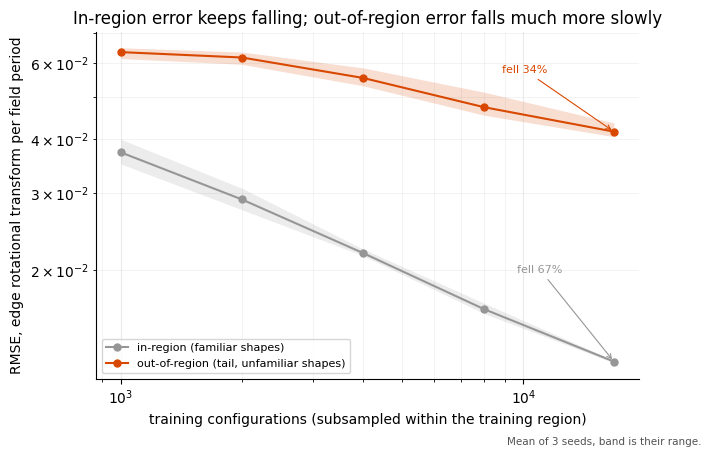

In [242]:
cells = load_results('n_sweep')['results']['cells']
clean = [c for c in cells if c['sigma'] == 0.0]
sizes = sorted({c['n_train'] for c in clean})
seeds_here = sorted({c['seed'] for c in clean})

# A single out/in ratio line was ambiguous about what was actually moving: a
# falling ratio could mean either curve doing the work. Two RMSE traces show it
# directly.
rmse_in = {(c['n_train'], c['seed']): c['in_region']['rmse'] for c in clean}
rmse_out = {(c['n_train'], c['seed']): c['out_region']['rmse'] for c in clean}

in_curves = [[rmse_in[(n, s)] for n in sizes] for s in seeds_here]
out_curves = [[rmse_out[(n, s)] for n in sizes] for s in seeds_here]

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 4.5))

in_mean = band(ax, sizes, in_curves, COLOR_TRAIN)
ax.plot(sizes, in_mean, 'o-', color=COLOR_TRAIN, markersize=5, label='in-region (familiar shapes)')

out_mean = band(ax, sizes, out_curves, COLOR_TAIL)
ax.plot(
    sizes, out_mean, 'o-', color=COLOR_TAIL, markersize=5,
    label='out-of-region (tail, unfamiliar shapes)',
)

# Computed from the plotted means, not quoted from a prior write-up: an earlier
# draft of this figure's caption used a seed-0-only fall (29%) for the
# out-of-region side while pairing it with the three-seed mean (67%) for the
# in-region side. The three-seed fall for both is 67% and 34%.
in_fall = 1 - in_mean[-1] / in_mean[0]
out_fall = 1 - out_mean[-1] / out_mean[0]

ax.annotate(
    f'fell {in_fall:.0%}',
    xy=(sizes[-1], in_mean[-1]),
    xytext=(sizes[2] * 2.75, 0.02),
    ha='center',
    va='center',
    fontsize=8,
    color=COLOR_TRAIN,
    arrowprops={'arrowstyle': '->', 'color': COLOR_TRAIN, 'lw': 0.8},
)
ax.annotate(
    f'fell {out_fall:.0%}',
    xy=(sizes[-1], out_mean[-1]),
    xytext=(sizes[-1] * 0.6, out_mean[-1] * 1.35),
    ha='center',
    va='bottom',
    fontsize=8,
    color=COLOR_TAIL,
    arrowprops={'arrowstyle': '->', 'color': COLOR_TAIL, 'lw': 0.8},
)


ax.set_xscale('log')
ax.set_yscale('log')
ax.minorticks_on()
ax.grid(which='minor', color=COLOR_NEUTRAL, alpha=0.12, linewidth=0.4)

ax.set_xlabel('training configurations (subsampled within the training region)')
ax.set_ylabel('RMSE, edge rotational transform per field period')
ax.set_title('In-region error keeps falling; out-of-region error falls much more slowly')
ax.legend(fontsize=8, loc='lower left')

fig.text(
    0.99,
    -0.02,
    f'Mean of {len(seeds_here)} seeds, band is their range.',
    ha='right',
    va='top',
    fontsize=7.5,
    color=COLOR_NEUTRAL,
)

keep(fig, 'gap_vs_n')

# Supporting evidence

Everything above is a deliverable. What follows is the evidence from the
earlier gates, kept because each one answers an obvious objection to the
results above rather than because it stands on its own.

Reads `results/*.json`, so it needs those scripts to have been run. Fast.


In [243]:
noise = load_results('stage_2_noise_floor')['results']

print('noise floor targets:', list(noise['residual_spread']))


noise floor targets: ['edge_rot_transform', 'log10_qi']


## Figure 11: the noise floor

The dashed line is fitted to the three closest bins and extended back to zero
distance. Its intercept is the floor estimate, which is the point of the figure.

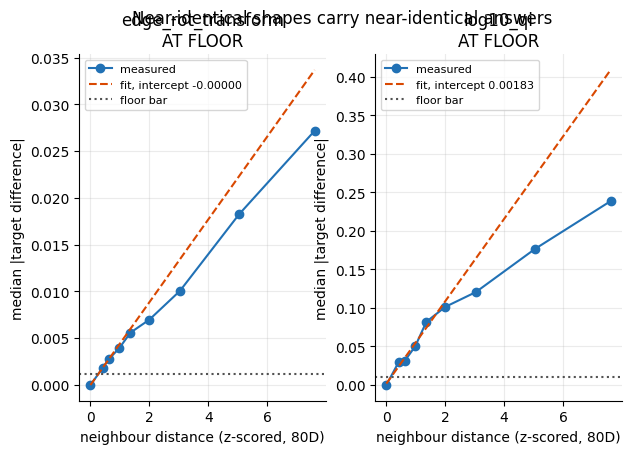

In [244]:
spread = noise['residual_spread']

fig, axes = plt.subplots(1, len(spread), figsize=(FIG_WIDTH, 4.5))
axes = np.atleast_1d(axes)

for ax, (name, result) in zip(axes, spread.items(), strict=False):
    d = [b['median_distance'] for b in result['bins']]
    gap = [b['median_delta'] for b in result['bins']]

    ax.plot(d, gap, 'o-', color=COLOR_HOLE, label='measured')

    xs = np.linspace(0, max(d), 50)
    ax.plot(
        xs,
        result['intercept'] + result['slope'] * xs,
        '--',
        color=COLOR_TAIL,
        label=f'fit, intercept {result["intercept"]:.5f}',
    )
    ax.axhline(result['bar'], color=COLOR_NEUTRAL, linestyle=':', label='floor bar')

    ax.set_xlabel('neighbour distance (z-scored, 80D)')
    ax.set_ylabel('median |target difference|')
    ax.set_title(f'{name}\n{result["verdict"]}')
    ax.legend(fontsize=8)

fig.suptitle('Near-identical shapes carry near-identical answers')

keep(fig, 'noise_floor')

## Save

Writes everything stashed in `FIGS` to `figures/` as PNG and PDF. Only the
figures whose cells you have run are present, so re-run a cell before saving if
you changed it.

In [245]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# PDFs embed a creation timestamp, so without this every run rewrites all 13
# of them with identical content and git shows a diff that means nothing. PNGs
# are already deterministic, which is what makes them the regression check: if a
# PNG changes after a refactor, the figure really changed.
PDF_METADATA = {'CreationDate': None}

# savefig.bbox is 'tight', which crops each figure to whatever it actually drew,
# so a figure with short axis labels came out narrower than its neighbours. These
# two zero-alpha anchors sit at the left and right edges of the canvas, which
# pins the horizontal extent to FIG_WIDTH while leaving the vertical crop free to
# expand for the captions that sit below the axes.
for fig in FIGS.values():
    for x in (0.0, 1.0):
        fig.text(x, 0.5, ' ', alpha=0)

for name, fig in FIGS.items():
    fig.savefig(FIGURES_DIR / f'{name}.png')
    fig.savefig(FIGURES_DIR / f'{name}.pdf', metadata=PDF_METADATA)
    print(f'wrote figures/{name}.png and .pdf')


wrote figures/split_design.png and .pdf
wrote figures/distance_error.png and .pdf
wrote figures/coverage_distance.png and .pdf
wrote figures/pit_distance.png and .pdf
wrote figures/coverage_nominal.png and .pdf
wrote figures/pit_histograms.png and .pdf
wrote figures/recalibration.png and .pdf
wrote figures/recalibration_coverage.png and .pdf
wrote figures/deferral_curve_mae.png and .pdf
wrote figures/solver_failures.png and .pdf
wrote figures/n_sweep.png and .pdf
wrote figures/gap_vs_n.png and .pdf
wrote figures/noise_floor.png and .pdf


## Scratch

Prototype new figures here. When one settles, give it a `keep(fig, 'name')` and
move the cell up into the body above, so the save cell writes it in order.